In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tree import Tree
from tree_tensor import TreeBasedTensor
from tree_cross import TreeCross

rng = np.random.default_rng()

In [8]:
Nx = 100    # spatial resolution
Ny = 5       # parameter resolution
n_a_param = 20 # number of parameters for diffusion coeff
n_param = n_a_param
offset = 1   # parameter mean
var = 4       # 'variance' of the parameters
tol = 1e-4
N_MC = 500

In [9]:
class diffusion_coeff:
  def __init__(self, Nx, Ny, offset, var):
    self.Nx = Nx
    self.Ny = Ny
    self.offset = offset
    self.var = var

  def __call__(self, X):
    c = np.full(len(X), self.offset,dtype=float)
    for i, x in enumerate(X):
      k = np.arange(1,len(x)-1)
      # k = k[k != 7]
      c[i] += np.sum(k**-2. * np.sin(np.pi*k*x[0]/(self.Nx-1)) \
                      * (x[k]/(self.Ny-1) - 0.5) * self.var)
    return np.exp(c)
  
def RMS(x, **kwargs):
  return np.sqrt(np.mean(np.square(x), **kwargs))
  
def err_MC(tensor, cfun, N_MC=500):
  N_MC = 500
  errs = np.zeros(N_MC)

  for i in range(N_MC):
    # eval TT-approx of coeff
    y = rng.integers(0, Ny, n_a_param)
    C_eval = np.ravel(tensor[:, *y])

    X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])
    C_true = cfun(X)

    errs[i] = RMS(C_eval-C_true)

  return errs

In [10]:
def linear_tupletree(n):
  tuple = (n,)
  for i in reversed(range(n)):
    tuple = (i, tuple)

  return tuple

def balanced_binary_tupletree(n):
  def worker(indices):
    if len(indices) == 1:
      return indices[0]
    else:
      middle = len(indices) // 2
      sub_l = worker(indices[:middle])
      sub_r = worker(indices[middle:])
      return (sub_l, sub_r)
    
  return (0, worker([i+1 for i in range(n)]))

def invert_tupletree(tupletree):
  if isinstance(tupletree, tuple):
    return tuple(invert_tupletree(e) for e in tupletree[::-1])
  else:
    return tupletree

In [11]:
cfun = diffusion_coeff(Nx, Ny, offset, var)

param_shape = tuple([Ny] * n_param)

# tree = Tree.from_tupletree((0,(1,((2,3), (4,(5,6))))))
tree = Tree.from_tupletree(linear_tupletree(n_a_param))
tree = Tree.from_tupletree(balanced_binary_tupletree(n_a_param))

tree.print()
C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, Ny)

res = {}
for kickrank in [2,4,8]:
  C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, 2)
  res[kickrank] = {'n_eval':[], 'err':[]}
  n_eval_over_iter = []
  cross = TreeCross(C_a)
  iter = 0
  while cross.n_eval < 5e5 and iter < 10:
    cross.run(cfun, n_iter=1, eps=tol, kickrank=kickrank, verbose=1)
    # C_a.print()

    C_a_test = C_a.copy()
    C_a_test.round(tol=tol)
    # C_a_test.print()
    errs = err_MC(C_a_test, cfun)

    res[kickrank]['err'] += [RMS(errs)]
    res[kickrank]['n_eval'] += [cross.n_eval]
    iter += 1

C_a_test.print()

[40] (root) 
 + [0] (dim 0)
 + [39] 
    + [19] 
    |  + [9] 
    |  |  + [3] 
    |  |  |  + [1] (dim 1)
    |  |  |  + [2] (dim 2)
    |  |  + [8] 
    |  |     + [4] (dim 3)
    |  |     + [7] 
    |  |        + [5] (dim 4)
    |  |        + [6] (dim 5)
    |  + [18] 
    |     + [12] 
    |     |  + [10] (dim 6)
    |     |  + [11] (dim 7)
    |     + [17] 
    |        + [13] (dim 8)
    |        + [16] 
    |           + [14] (dim 9)
    |           + [15] (dim 10)
    + [38] 
       + [28] 
       |  + [22] 
       |  |  + [20] (dim 11)
       |  |  + [21] (dim 12)
       |  + [27] 
       |     + [23] (dim 13)
       |     + [26] 
       |        + [24] (dim 14)
       |        + [25] (dim 15)
       + [37] 
          + [31] 
          |  + [29] (dim 16)
          |  + [30] (dim 17)
          + [36] 
             + [32] (dim 18)
             + [35] 
                + [33] (dim 19)
                + [34] (dim 20)

swp: 1/1 f_evals=1624 self.max_dx=3.47e+08
swp: 1/1 f_evals=5760

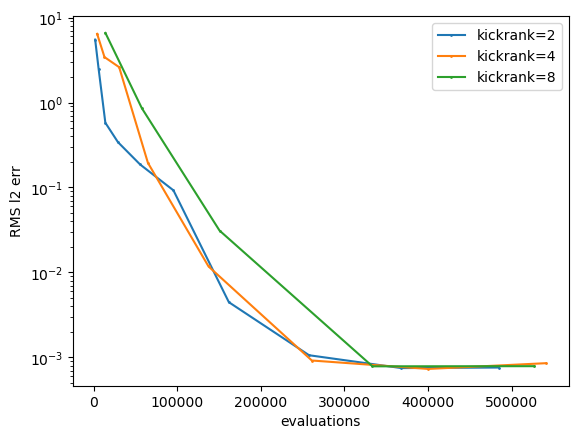

In [12]:
fig, ax = plt.subplots()
for kickrank, data in res.items():
  ax.plot(data['n_eval'], data['err'], marker='o', ms=1, label=f'kickrank={kickrank}')
ax.set_yscale('log')
ax.set_ylabel('RMS l2 err')
ax.set_xlabel('evaluations')
ax.legend()

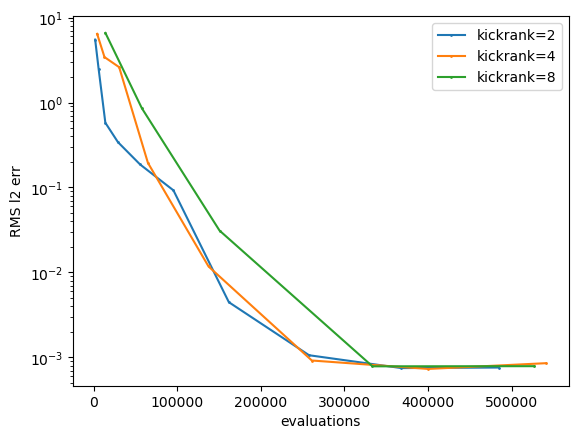

In [13]:
fig, ax = plt.subplots()
for kickrank, data in res.items():
  ax.plot(data['n_eval'], data['err'], marker='o', ms=1, label=f'kickrank={kickrank}')
ax.set_yscale('log')
ax.set_ylabel('RMS l2 err')
ax.set_xlabel('evaluations')
ax.legend()

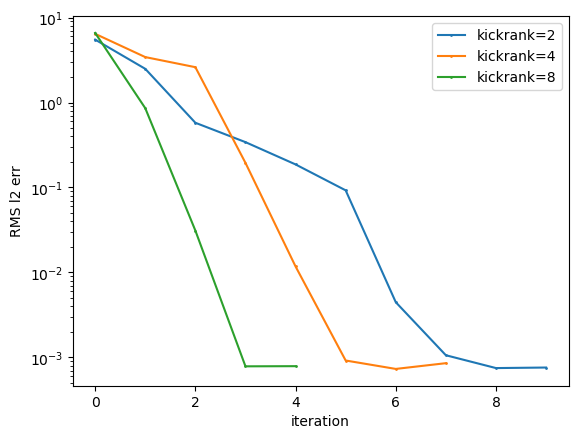

In [14]:
fig, ax = plt.subplots()
for kickrank, data in res.items():
  ax.plot(data['err'], marker='o', ms=1, label=f'kickrank={kickrank}')
ax.set_yscale('log')
ax.set_ylabel('RMS l2 err')
ax.set_xlabel('iteration')
ax.legend()

RMS l2 err = 8.07e-04


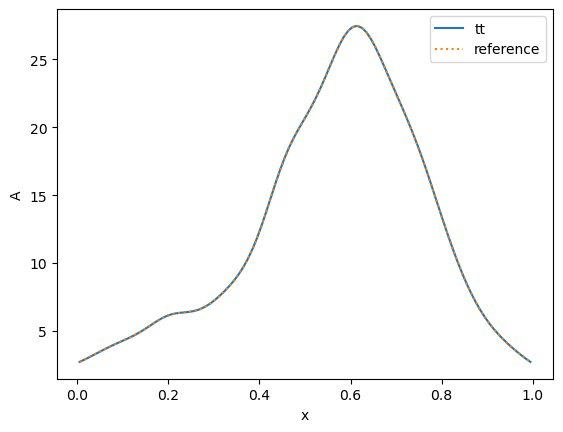

In [15]:
errs = err_MC(C_a_test, cfun, N_MC=N_MC)

print(f'RMS l2 err = {RMS(errs):.2e}')
# N_MC = 500
# errs = np.zeros(N_MC)

# for i in range(N_MC):
#   # eval TT-approx of coeff
#   y = rng.integers(0, Ny, n_a_param)
#   C_eval = np.ravel(C_a[:, *y])

#   X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])
#   C_true = cfun(X)

#   errs[i] = RMS(C_eval-C_true)

fig, ax = plt.subplots()
y = rng.integers(0, Ny, n_a_param)
C_eval = np.ravel(C_a[:, *y])
X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])
C_true = cfun(X)

x = (np.arange(0, Nx) + .5) / Nx
ax.plot(x, C_eval, label='tt')
ax.plot(x, C_true, ls='dotted', label="reference")
ax.set_xlabel('x')
ax.set_ylabel('A')
ax.legend()

In [ ]:
runs = 10

errs_linear = []
evals_linear = []

for run in range(runs):
  tree = Tree.from_tupletree((0,(1,(2,(3,(4,(5,(6,(7,8)))))))))
  C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, Ny)

  cross = TreeCross(C_a)
  cross.run(cfun, n_iter=25, eps=1e-9, kickrank=40, verbose=False)
  C_a.round(tol=tol)

  errs = err_MC(C_a, cfun)

  errs_linear += [np.sqrt(np.mean(np.square(errs)))]
  evals_linear += [cross.n_eval]

AssertionError: Tree order must match shape (9 != 4).

In [ ]:
errs_fancy = []
evals_fancy = []

for run in range(runs):
  tree = Tree.from_tupletree((0,(1,((2,(3,4), (5,(6,(7,8))))))))
  C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, Ny)

  cross = TreeCross(C_a)
  cross.run(cfun, n_iter=25, eps=1e-9, kickrank=40, verbose=False)
  C_a.round(tol=tol)

  errs = err_MC(C_a, cfun)

  errs_fancy += [np.sqrt(np.mean(np.square(errs)))]
  evals_fancy += [cross.n_eval]

In [ ]:
errs_balanced = []
evals_balanced = []

for run in range(runs):
  tree = Tree.from_tupletree((0,(((1,2),(3,4)),((5,6),(7,8)))))
  C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, Ny)

  cross = TreeCross(C_a)
  cross.run(cfun, n_iter=25, eps=1e-9, kickrank=40, verbose=False)
  C_a.round(tol=tol)

  errs = err_MC(C_a, cfun)

  errs_balanced += [np.sqrt(np.mean(np.square(errs)))]
  evals_balanced += [cross.n_eval]

In [ ]:
print(np.mean(evals_linear))
print(np.mean(evals_fancy))
print(np.mean(evals_balanced))

253897.5
253056.5
254680.0


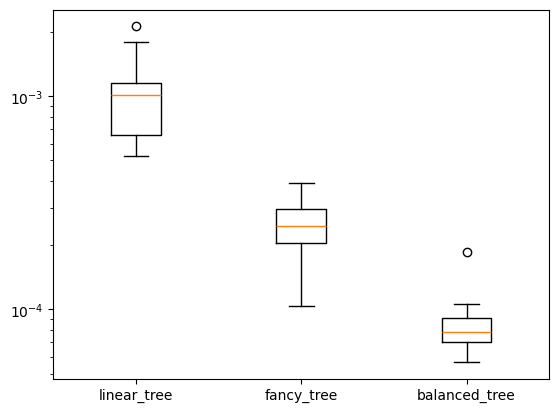

In [ ]:
fig, ax = plt.subplots()

ax.boxplot([errs_linear,errs_fancy, errs_balanced], tick_labels=['linear_tree', 'fancy_tree', 'balanced_tree'])
ax.set_yscale('log')